# Texas GOP Senate Runoff Win-Probability Analysis

This notebook estimates a fair probability for the May 26, 2026 Texas Republican U.S. Senate runoff between Ken Paxton and John Cornyn. It uses public verified data only and keeps prediction markets out of the model so markets can be compared afterward.

Run the pipeline cell first. It reads `data/raw/*.csv`, validates the core source values, and regenerates `data/processed/*`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from scripts.build_dataset import main

result = main()

Full model: Paxton 60.2%, Cornyn 39.8%, mean Paxton margin 2.2 pts
Wrote processed outputs to C:\Users\dg\Desktop\Ken Paxton vs John Cornyn\data\processed


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

processed = ROOT / 'data' / 'processed'
polls = pd.read_csv(processed / 'polls.csv')
scenarios = pd.read_csv(processed / 'model_scenarios.csv')
markets = pd.read_csv(processed / 'market_comparison.csv')
sensitivity = pd.read_csv(processed / 'sensitivity.csv')
primary = pd.read_csv(processed / 'primary_results.csv')
finance = pd.read_csv(processed / 'finance_ads.csv')
hunt_transfer = pd.read_csv(processed / 'hunt_transfer.csv')
subgroups = pd.read_csv(processed / 'subgroup_signals.csv')
candidate_strength = pd.read_csv(processed / 'candidate_strength.csv')
turnout = pd.read_csv(processed / 'turnout_signals.csv')
general = pd.read_csv(processed / 'general_election_polls.csv')
model_output = json.loads((processed / 'model_output.json').read_text())

model_output['headline']

{'as_of': '2026-05-03',
 'paxton_fair_probability': 0.60163,
 'cornyn_fair_probability': 0.39837,
 'mean_paxton_margin_points': 2.2008022687773354,
 'margin_80pct_interval': [-8.64054618532317, 13.034008942276266]}

## Core Runoff Polls

The model uses direct post-primary runoff polls. Polls are weighted by recency, sample size, voter population, and whether they are sponsor-linked/internal.

In [3]:
core_cols = [
    'pollster', 'release_date', 'sample_size', 'population', 'paxton_pct',
    'cornyn_pct', 'other_undecided_pct', 'two_candidate_margin', 'model_weight'
]
polls[polls['model_group'] == 'core'][core_cols].sort_values('release_date')

,pollster,release_date,sample_size,population,paxton_pct,cornyn_pct,other_undecided_pct,two_candidate_margin,model_weight
9,Texas Public Opinion Research,2026-03-09,781,LV,49,41,10,8.888889,0.173848
10,Public Policy Polling,2026-03-13,565,LV,45,42,13,3.448276,0.168735
11,Change Research,2026-03-19,811,RV,42,39,19,3.703704,0.184826
12,Impact Research,2026-03-20,900,LV,53,37,10,17.777778,0.170114
13,Quantus Insights,2026-03-24,1218,LV,49,41,10,8.888889,0.356195
14,GQR,2026-03-30,600,LV,47,42,11,5.617978,0.169318
15,co/efficient,2026-04-14,1143,LV,43,44,13,-1.149425,0.713267
16,Texas Public Opinion Research,2026-04-16,1225,LV,48,40,12,9.090909,0.605743
34,Peak Insights,2026-04-17,800,LV,43,44,13,-1.149425,0.354159


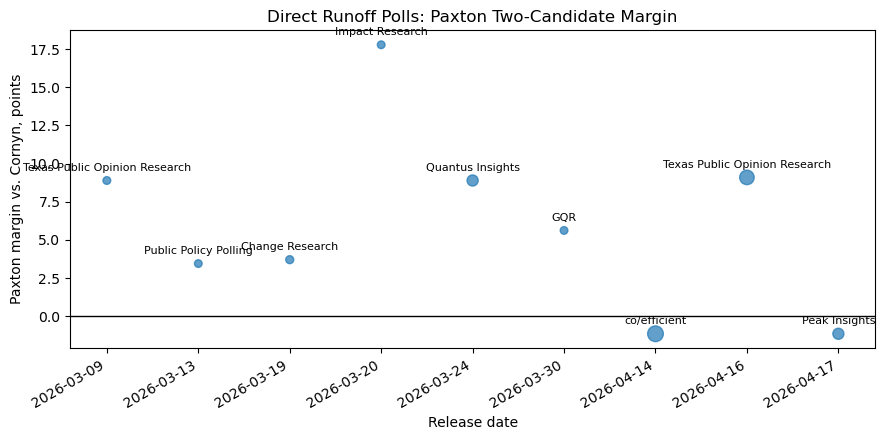

In [4]:
core = polls[polls['model_group'] == 'core'].copy().sort_values('release_date')
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(0, color='black', linewidth=1)
ax.scatter(core['release_date'], core['two_candidate_margin'], s=core['model_weight'] * 180, alpha=0.7)
for _, row in core.iterrows():
    ax.annotate(row['pollster'], (row['release_date'], row['two_candidate_margin']), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=8)
ax.set_title('Direct Runoff Polls: Paxton Two-Candidate Margin')
ax.set_ylabel('Paxton margin vs. Cornyn, points')
ax.set_xlabel('Release date')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

## Expanded Inputs

These tables capture model-relevant transfer data plus contextual signals that explain the runoff electorate.

In [5]:
hunt_transfer[[
    'pollster', 'release_date', 'paxton_pct', 'cornyn_pct', 'undecided_other_pct',
    'usable_in_model', 'model_weight', 'explicit_two_candidate_paxton_share'
]].sort_values('release_date')

,pollster,release_date,paxton_pct,cornyn_pct,undecided_other_pct,usable_in_model,model_weight,explicit_two_candidate_paxton_share
0,University of Houston Hobby School,2026-02-09,48,35.0,17.0,True,0.140224,0.578313
1,McLaughlin & Associates,2026-03-01,50,35.0,16.0,True,0.152346,0.588235
2,Texas Public Opinion Research,2026-03-09,48,31.0,21.0,True,0.376359,0.607595
3,Change Research,2026-03-19,49,31.0,20.0,True,0.349770,0.612500
4,Quantus Insights,2026-03-24,58,NaN,NaN,False,0.000000,NaN
5,Texas Public Opinion Research,2026-04-17,45,32.0,24.0,True,0.853827,0.584416


In [6]:
subgroups[['source', 'group_name', 'paxton_pct', 'cornyn_pct', 'leader', 'notes']].head(30)

,source,group_name,paxton_pct,cornyn_pct,leader,notes
0,Change Research,All voters,42,39,Paxton,Potential Texas Republican runoff voters.
1,Change Research,Strong Republican,48,36,Paxton,Paxton strength with strong Republicans.
2,Change Research,Not strong Republican,27,49,Cornyn,Cornyn strength with weaker party identifiers.
3,Change Research,Independent/Lean Republican,47,32,Paxton,Paxton strength among Republican-leaning indep...
4,Change Research,MAGA Republican,54,35,Paxton,MAGA alignment split.
5,Change Research,Not MAGA Republican,22,51,Cornyn,Cornyn strength with non-MAGA Republicans.
6,Change Research,March Paxton voter,92,3,Paxton,Paxton retention.
7,Change Research,March Cornyn voter,6,83,Cornyn,Cornyn retention.
8,Change Research,March Hunt voter,49,31,Paxton,Hunt transfer; residual includes unclear/no-vote.
9,Change Research,Not a March voter,26,31,Cornyn,Cornyn small lead with new runoff voters; high...


In [7]:
display(turnout)
display(general[['pollster', 'release_date', 'matchup', 'republican_pct', 'democrat_pct', 'other_undecided_pct']])

,source,signal_date,stage,metric,value,unit,source_url,notes
0,TXElectionResults,2026-03-03,primary,gop_ballots,2166910.0,votes,https://txelectionresults.com/primaries/2026,"Combined primary result site, 254/254 counties."
1,TXElectionResults,2026-03-03,primary,dem_ballots,2319187.0,votes,https://txelectionresults.com/primaries/2026,"Combined primary result site, 254/254 counties."
2,TXElectionResults,2026-03-03,primary,total_ballots,4486097.0,votes,https://txelectionresults.com/primaries/2026,"Combined primary result site, 254/254 counties."
3,TexPolls/TX SOS,2026-03-03,primary,gop_early_vote,1081878.0,votes,https://texpolls.com/,Final primary turnout estimate from SOS-linked...
4,TexPolls/TX SOS,2026-03-03,primary,gop_election_day_vote,1071472.0,votes,https://texpolls.com/,"Derived from GOP final 2,153,350 minus early 1..."
5,TexPolls/TX SOS,2026-03-03,primary,dem_early_vote,1214638.0,votes,https://texpolls.com/,Final primary turnout estimate from SOS-linked...
6,TexPolls/TX SOS,2026-03-03,primary,dem_election_day_vote,983259.0,votes,https://texpolls.com/,"Derived from Dem final 2,197,897 minus early 1..."
7,Lines prediction market,2026-04-18,runoff,turnout_0_6m_to_0_9m_probability,58.0,percent,https://www.lines.com/prediction-markets/elect...,Market-implied modal lower-turnout bin.
8,Polymarket,2026-04-27,runoff,turnout_0_9m_to_1_2m_probability,15.5,percent,https://polymarket.com/event/turnout-in-texas-...,Search-result snapshot referenced lower bins; ...
9,Polymarket,2026-04-27,runoff,total_turnout_market_volume,43600.0,usd,https://polymarket.com/event/turnout-in-texas-...,Turnout market liquidity signal.


,pollster,release_date,matchup,republican_pct,democrat_pct,other_undecided_pct
0,Public Policy Polling,2026-03-05,Cornyn vs Talarico,43,44,13
1,Public Policy Polling,2026-03-05,Paxton vs Talarico,45,47,8
2,Impact Research,2026-03-20,Cornyn vs Talarico,41,43,16
3,Impact Research,2026-03-20,Paxton vs Talarico,43,44,13
4,Texas Public Opinion Research,2026-04-28,Cornyn vs Talarico,41,44,15
5,Texas Public Opinion Research,2026-04-28,Paxton vs Talarico,43,45,12
6,University of Texas,2026-04-29,Cornyn vs Talarico,33,40,27
7,University of Texas,2026-04-29,Paxton vs Talarico,34,42,24


## Scenario Output

The headline model is `full_model_mid_turnout`. The low- and high-turnout scenarios bracket plausible runoff electorate composition.

In [8]:
display_cols = [
    'scenario', 'paxton_win_probability', 'cornyn_win_probability',
    'mean_paxton_margin_points', 'margin_80pct_low', 'margin_80pct_high', 'note'
]
scenarios[display_cols]

,scenario,paxton_win_probability,cornyn_win_probability,mean_paxton_margin_points,margin_80pct_low,margin_80pct_high,note
0,polling_only,0.708560,0.291440,4.914424,-6.596492,16.512506,Only post-primary direct runoff polls.
1,polling_plus_primary,0.685315,0.314685,4.071018,-6.754913,14.940487,Runoff polls blended with first-round result p...
2,full_model_mid_turnout,0.601630,0.398370,2.200802,-8.640546,13.034009,"Core estimate: polls, primary prior, Paxton en..."
3,low_turnout,0.647185,0.352815,3.450802,-8.368258,15.219774,Lower-turnout runoff scenario; assumes more id...
4,high_turnout,0.539000,0.461000,0.950802,-10.924841,12.778680,Higher-turnout runoff scenario; assumes Cornyn...


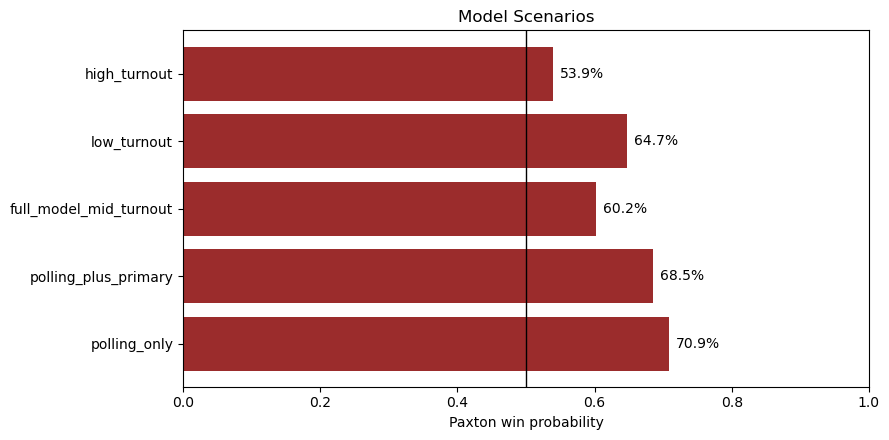

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = scenarios.copy()
ax.barh(plot_df['scenario'], plot_df['paxton_win_probability'], color='#9b2c2c')
ax.axvline(0.5, color='black', linewidth=1)
ax.set_xlim(0, 1)
ax.set_xlabel('Paxton win probability')
ax.set_title('Model Scenarios')
for i, value in enumerate(plot_df['paxton_win_probability']):
    ax.text(value + 0.01, i, f'{value:.1%}', va='center')
plt.tight_layout()

## Market Comparison

The model's fair probability is compared to prediction-market snapshots. A positive edge means the model is higher than the market-implied probability. This is not financial advice.

In [10]:
market_cols = [
    'platform', 'timestamp', 'paxton_implied_prob', 'cornyn_implied_prob',
    'paxton_model_edge_vs_market', 'cornyn_model_edge_vs_market',
    'paxton_value_below_with_5pt_buffer', 'cornyn_value_below_with_5pt_buffer'
]
markets[market_cols]

,platform,timestamp,paxton_implied_prob,cornyn_implied_prob,paxton_model_edge_vs_market,cornyn_model_edge_vs_market,paxton_value_below_with_5pt_buffer,cornyn_value_below_with_5pt_buffer
0,Kalshi,2026-03-04,0.55,0.45,0.05163,-0.05163,0.55163,0.34837
1,Polymarket,2026-03-14,0.39,0.61,0.21163,-0.21163,0.55163,0.34837
2,Kalshi,2026-03-14,0.55,0.45,0.05163,-0.05163,0.55163,0.34837
3,Polymarket,2026-04-18,0.60,0.40,0.00163,-0.00163,0.55163,0.34837
4,Covers/Kalshi,2026-05-01,0.59,0.41,0.01163,-0.01163,0.55163,0.34837
5,Polymarket,2026-05-03,0.56,0.42,0.04163,-0.02163,0.55163,0.34837


## Sensitivity

Leave-one-pollster-out checks identify whether one source is carrying the headline estimate.

In [11]:
sensitivity.sort_values('paxton_win_probability')

,removed_pollster,paxton_win_probability,mean_paxton_margin_points
6,Texas Public Opinion Research,0.549875,1.105186
5,Quantus Insights,0.580520,1.799507
2,Impact Research,0.584150,1.622857
1,GQR,0.599920,2.169349
0,Change Research,0.601760,2.260224
4,Public Policy Polling,0.602030,2.266109
8,all partisan/internal core polls,0.611925,2.148568
3,Peak Insights,0.632370,2.809071
7,co/efficient,0.677635,3.627368


## Money and Ads

Cornyn has the stronger financial and paid-media position. The model caps this adjustment because the first round showed Paxton remained competitive despite being heavily outspent.

In [12]:
finance.sort_values(['stage', 'candidate_affinity', 'entity'])

,entity,candidate_affinity,entity_type,stage,date_start,date_end,receipts_m,disbursements_m,cash_on_hand_m,ad_support_m,ad_spending_m,source_url,notes
5,Cornyn campaign and associated victory funds,Cornyn,campaign+JFC,primary,2025-01-01,2026-02-27,NaN,NaN,NaN,69.0,15.100,https://adimpact.com/blogs/tx-senate-ad-analys...,AdImpact: Cornyn received $69M total ad suppor...
7,Wesley Hunt ad support,Hunt,campaign+allies,primary,2025-01-01,2026-02-27,NaN,NaN,NaN,12.0,11.500,https://adimpact.com/blogs/tx-senate-ad-analys...,Included because Hunt-voter transfer is centra...
6,Ken Paxton ad support,Paxton,campaign+allies,primary,2025-01-01,2026-02-27,NaN,NaN,NaN,4.1,3.700,https://adimpact.com/blogs/tx-senate-ad-analys...,AdImpact: Paxton trailed heavily in ad support.
4,Conservative Texans PAC,Cornyn,super PAC,runoff,2026-01-01,2026-03-31,5.0,NaN,1.95,NaN,NaN,https://www.texastribune.org/2026/04/15/john-c...,Pro-Cornyn spender in runoff.
9,Cornyn Lonestar Victory Committee,Cornyn,JFC,runoff,2026-03-04,2026-04-15,NaN,NaN,NaN,NaN,0.545,https://www.texastribune.org/2026/04/15/john-c...,Additional runoff spend.
0,John Cornyn campaign and joint fundraising com...,Cornyn,campaign+JFC,runoff,2026-01-01,2026-03-31,9.0,17.0,8.20,NaN,NaN,https://www.texastribune.org/2026/04/15/john-c...,Q1 2026 totals across accounts under Cornyn co...
2,Texans for a Conservative Majority,Cornyn,super PAC,runoff,2026-01-01,2026-03-31,9.5,NaN,2.90,NaN,NaN,https://www.texastribune.org/2026/04/15/john-c...,Main pro-Cornyn PAC; Q1 fundraising and cash o...
8,Texans for a Conservative Majority,Cornyn,super PAC,runoff,2026-03-04,2026-04-15,NaN,NaN,NaN,NaN,2.850,https://www.texastribune.org/2026/04/15/john-c...,Runoff ads spent or booked through Tuesday bef...
1,Ken Paxton campaign and joint fundraising comm...,Paxton,campaign+JFC,runoff,2026-01-01,2026-03-31,2.2,3.2,2.60,NaN,NaN,https://www.texastribune.org/2026/04/15/john-c...,Q1 2026 totals across Paxton campaign and new ...
3,Lone Star Liberty PAC,Paxton,super PAC,runoff,2026-01-01,2026-03-31,2.1,NaN,1.00,NaN,NaN,https://www.texastribune.org/2026/04/15/john-c...,Main pro-Paxton PAC; Q1 fundraising and cash o...


## Caveats

- Runoff turnout is the largest structural uncertainty.
- A late Trump endorsement is not assigned quantitatively until reflected in polling or market movement.
- Sponsor-linked polls are retained but downweighted.
- Prediction markets may be thin, fee-affected, or inaccessible depending on jurisdiction.